# Enhanced Autonomous Navigation Using Reinforcement Learning


## Q-Learning vs DQN

This Jupyter notebook implements the experimental methodology described in the uploaded paper **“Comparison of Q-Learning and Deep Q-Network for Autonomous Navigation in Grid-Based Environments.”**

The paper uses a 10×10 gridworld with fixed obstacles and compares tabular Q-learning with a PyTorch DQN.

**Important:** the paper does not specify every implementation detail. Where a choice is necessary but not explicitly reported, it is marked in the code as an **implementation assumption** rather than being presented as an exact statement from the paper.



## Paper-specified setup

**Environment**
- Grid: 10×10
- Start: (1,1)
- Goal: (10,10)
- Obstacles: (3,3), (3,4), (3,5), (4,5), (5,5), (5,6), (6,6), (7,4), (7,5), (8,5)
- Actions: right, left, down, up
- Goal reward: +100
- Obstacle reward: −100
- Normal step reward: −1
- Maximum episode length: 200 steps

**Q-learning**
- α = 0.1
- γ = 0.9
- ε = 0.1 fixed
- 1000 episodes/run
- 20 independent runs
- Q-table initialized to zero

**DQN**
- 2 hidden layers, 64 neurons each
- ReLU activations
- Adam learning rate = 0.001
- γ = 0.9
- ε = 0.2 fixed
- Replay buffer = 50,000
- Batch size = 64
- Target network update = every 50 episodes
- 500 episodes/run
- 5 independent runs
- Maximum episode length = 200

**Reported paper results**
- Q-learning success rate = 99.11%
- Q-learning successful path length = 28.51 ± 19.64
- Q-learning convergence ≈150–200 episodes
- DQN success rate = 52.52%
- DQN convergence = 293.6 episodes


### Prompt 

Create the Python environment for this reproduction notebook. Import NumPy, Pandas, Matplotlib, PyTorch, and the standard-library utilities required for Q-learning and DQN, and verify the installed package versions.

In [4]:

# Install dependencies
# %pip install -q numpy pandas matplotlib torch

import os
import random
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)


PyTorch: 2.8.0
NumPy: 1.26.4


### Inference

The output shows **PyTorch 2.8.0** and **NumPy 1.26.4**, confirming that the required numerical and deep-learning libraries are installed and import successfully.

### Prompt

Set up deterministic/reproducible random seeds for Python, NumPy, and PyTorch, including CUDA when available. Then select the computation device and print it.

In [7]:

# Reproducibility

GLOBAL_SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(GLOBAL_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


### Inference

The output is **`Device: cpu`**. Therefore, the stored experiments were configured to run on the CPU. The notebook also fixes the random seed, which improves repeatability, although exact reproduction can still differ when the paper leaves implementation details unspecified.

### Prompt

Define all environment settings and hyperparameters exactly as reported in the research paper: the 10×10 grid, start and goal positions, ten fixed obstacles, four actions, rewards, 200-step limit, Q-learning parameters, DQN parameters, replay-buffer settings, target-network frequency, and convergence criterion.

In [10]:

# Exact parameters reported by the paper

GRID_SIZE = 10
START = (1, 1)
GOAL = (10, 10)

OBSTACLES = {
    (3, 3), (3, 4), (3, 5), (4, 5), (5, 5),
    (5, 6), (6, 6), (7, 4), (7, 5), (8, 5)
}

# Action order used by this implementation:
# 0 = Right, 1 = Left, 2 = Down, 3 = Up
ACTIONS = {
    0: (0, 1),
    1: (0, -1),
    2: (1, 0),
    3: (-1, 0),
}

ACTION_NAMES = {
    0: "Right",
    1: "Left",
    2: "Down",
    3: "Up",
}

GOAL_REWARD = 100
OBSTACLE_REWARD = -100
STEP_REWARD = -1
MAX_STEPS = 200

Q_ALPHA = 0.1
Q_GAMMA = 0.9
Q_EPSILON = 0.1
Q_EPISODES = 1000
Q_RUNS = 20

DQN_GAMMA = 0.9
DQN_EPSILON = 0.2
DQN_LR = 0.001
DQN_EPISODES = 500
DQN_RUNS = 5
DQN_BUFFER_SIZE = 50_000
DQN_BATCH_SIZE = 64
DQN_TARGET_UPDATE_EPISODES = 50
DQN_HIDDEN = 64

CONVERGENCE_WINDOW = 50
CONVERGENCE_THRESHOLD = 50

print("Grid:", GRID_SIZE, "x", GRID_SIZE)
print("Start:", START)
print("Goal:", GOAL)
print("Obstacles:", sorted(OBSTACLES))


Grid: 10 x 10
Start: (1, 1)
Goal: (10, 10)
Obstacles: [(3, 3), (3, 4), (3, 5), (4, 5), (5, 5), (5, 6), (6, 6), (7, 4), (7, 5), (8, 5)]


### Inference

The output confirms **Grid: 10 × 10**, **Start: (1, 1)**, **Goal: (10, 10)**, and the exact ten obstacle coordinates.

### Prompt

Implement the custom 10×10 GridWorld used in the paper. The environment must support reset and step operations, enforce boundaries, handle obstacle collisions according to the documented implementation assumption, provide the rewards, terminate at the goal or 200 steps, record the path, and support visualization.

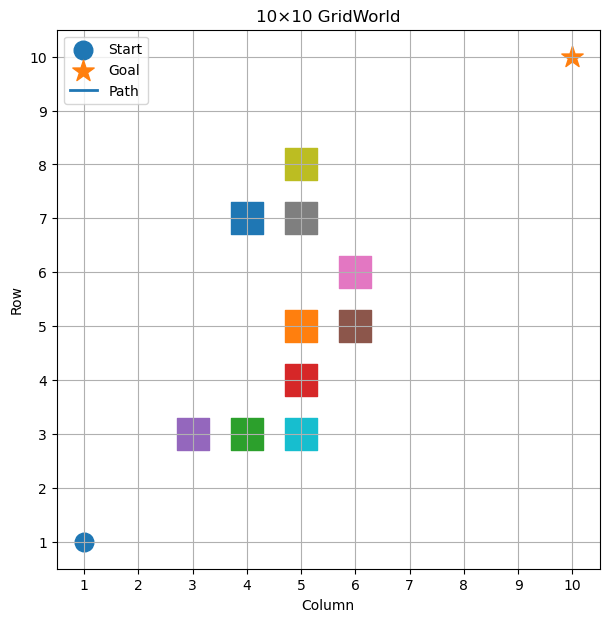

In [13]:

# Custom 10×10 GridWorld

class GridWorld:
    def __init__(self):
        self.grid_size = GRID_SIZE
        self.start = START
        self.goal = GOAL
        self.obstacles = set(OBSTACLES)
        self.reset()

    def reset(self):
        self.position = self.start
        self.steps = 0
        self.path = [self.position]
        return self.position

    def step(self, action):
        self.steps += 1

        dr, dc = ACTIONS[action]
        candidate = (
            self.position[0] + dr,
            self.position[1] + dc
        )

        # Paper: an out-of-grid action leaves the agent in its current cell.
        if not (1 <= candidate[0] <= self.grid_size and
                1 <= candidate[1] <= self.grid_size):
            next_position = self.position
            reward = STEP_REWARD
            done = False
            event = "boundary"

        elif candidate in self.obstacles:
            # IMPLEMENTATION ASSUMPTION:
            # The paper specifies -100 for hitting an obstacle, but does not
            # explicitly state whether collision terminates the episode.
            # Here the agent remains in place and the episode continues.
            next_position = self.position
            reward = OBSTACLE_REWARD
            done = False
            event = "obstacle"

        elif candidate == self.goal:
            next_position = candidate
            reward = GOAL_REWARD
            done = True
            event = "goal"

        else:
            next_position = candidate
            reward = STEP_REWARD
            done = False
            event = "move"

        self.position = next_position
        self.path.append(self.position)

        if self.steps >= MAX_STEPS and not done:
            done = True
            event = "timeout"

        return self.position, reward, done, {"event": event}

    def render(self, path=None, title="10×10 GridWorld"):
        path = self.path if path is None else path

        fig, ax = plt.subplots(figsize=(7, 7))
        ax.set_xlim(0.5, self.grid_size + 0.5)
        ax.set_ylim(0.5, self.grid_size + 0.5)
        ax.set_xticks(range(1, self.grid_size + 1))
        ax.set_yticks(range(1, self.grid_size + 1))
        ax.grid(True)

        for r, c in self.obstacles:
            ax.scatter(c, r, marker="s", s=500)

        ax.scatter(START[1], START[0], marker="o", s=180, label="Start")
        ax.scatter(GOAL[1], GOAL[0], marker="*", s=260, label="Goal")

        if path:
            xs = [p[1] for p in path]
            ys = [p[0] for p in path]
            ax.plot(xs, ys, linewidth=2, label="Path")

        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        ax.set_title(title)
        ax.legend()
        plt.show()

env = GridWorld()
env.render()


### Inference

The rendered output shows the constructed 10×10 gridworld with the start, goal, and fixed obstacles. This confirms visually that the environment used for training corresponds to the intended navigation problem before any learning results are interpreted.

### Prompt

Implement reusable utility functions for converting grid coordinates to Q-table indices, calculating moving averages, detecting the paper's convergence criterion, and selecting Q-learning actions with epsilon-greedy exploration.

In [16]:

# Utility functions

def state_to_index(state):
    r, c = state
    return (r - 1) * GRID_SIZE + (c - 1)

def moving_average(values, window=50):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return np.array([])
    return np.convolve(
        values,
        np.ones(window) / window,
        mode="valid"
    )

def convergence_episode(returns, window=50, threshold=50):
    # Paper definition:
    # first episode where the 50-episode moving average of returns > 50.
    ma = moving_average(returns, window)
    idx = np.where(ma > threshold)[0]

    if len(idx) == 0:
        return np.nan

    return int(idx[0] + window)

def epsilon_greedy_q(q_table, state, epsilon):
    s = state_to_index(state)

    if np.random.random() < epsilon:
        return np.random.randint(4)

    q_values = q_table[s]
    best = np.flatnonzero(q_values == q_values.max())
    return int(np.random.choice(best))



## Tabular Q-learning

The update below implements the Bellman equation described in the paper:

Q(s,a) ← Q(s,a) + α[r + γ max Q(s′,a′) − Q(s,a)]

The paper states that each independent run starts with a zero Q-table.


### Prompt

Implement tabular Q-learning for the paper's environment. Initialize a 100×4 zero Q-table, train for the requested number of episodes, use the Bellman Q-learning update with α=0.1 and γ=0.9, use ε-greedy exploration, record returns, successes, paths, and convergence, and return all information needed for later analysis.

In [19]:

def train_q_learning(episodes=Q_EPISODES, seed=0, epsilon=Q_EPSILON):
    set_seed(seed)

    env = GridWorld()

    # 100 states × 4 actions, initialized to zero as stated by the paper.
    q_table = np.zeros(
        (GRID_SIZE * GRID_SIZE, 4),
        dtype=np.float64
    )

    returns = []
    episode_steps = []
    successes = []
    successful_paths = []

    for episode in range(1, episodes + 1):
        state = env.reset()
        total_reward = 0
        success = False

        for step in range(1, MAX_STEPS + 1):
            action = epsilon_greedy_q(
                q_table,
                state,
                epsilon
            )

            next_state, reward, done, info = env.step(action)

            s = state_to_index(state)
            ns = state_to_index(next_state)

            # Q-learning target
            target = reward

            if not done:
                target += Q_GAMMA * np.max(q_table[ns])

            # Bellman update
            q_table[s, action] += Q_ALPHA * (
                target - q_table[s, action]
            )

            total_reward += reward
            state = next_state

            if done:
                success = info["event"] == "goal"
                break

        returns.append(total_reward)
        episode_steps.append(step)
        successes.append(int(success))

        if success:
            successful_paths.append(step)

    return {
        "q_table": q_table,
        "returns": np.asarray(returns),
        "steps": np.asarray(episode_steps),
        "successes": np.asarray(successes),
        "successful_paths": np.asarray(successful_paths),
        "convergence": convergence_episode(
            returns,
            CONVERGENCE_WINDOW,
            CONVERGENCE_THRESHOLD
        )
    }


### Prompt

Run one complete 1,000-episode Q-learning experiment with a fixed verification seed. Print its convergence episode, training success rate, and successful-path length statistics so the implementation can be checked before running all 20 independent trials.

In [21]:

# One Q-learning run for a quick verification

q_demo = train_q_learning(
    episodes=Q_EPISODES,
    seed=100
)

print("Convergence episode:", q_demo["convergence"])
print("Training success rate:",
      f"{100*q_demo['successes'].mean():.2f}%")

if len(q_demo["successful_paths"]) > 0:
    sd = (np.std(q_demo["successful_paths"], ddof=1)
          if len(q_demo["successful_paths"]) > 1 else 0.0)
    print("Successful path length:",
          f"{np.mean(q_demo['successful_paths']):.2f} ± {sd:.2f}")


Convergence episode: 151
Training success rate: 98.90%
Successful path length: 26.16 ± 19.58


### Inference

The actual output is **98.90% training success**, **convergence at episode 151**, and **26.16 ± 19.58 successful steps**. The result indicates that the Q-learning implementation learns the task reliably in the verification run. Its convergence at 151 is within the paper's reported approximately 150–200 episode range, while its success/path values are close to the paper's 99.11% and 28.51 ± 19.64.

### Prompt

Plot the Q-learning learning curve for the verification run. Show episode returns, the 50-episode moving average, and the convergence threshold of 50 so the learning and convergence behavior can be visually inspected.

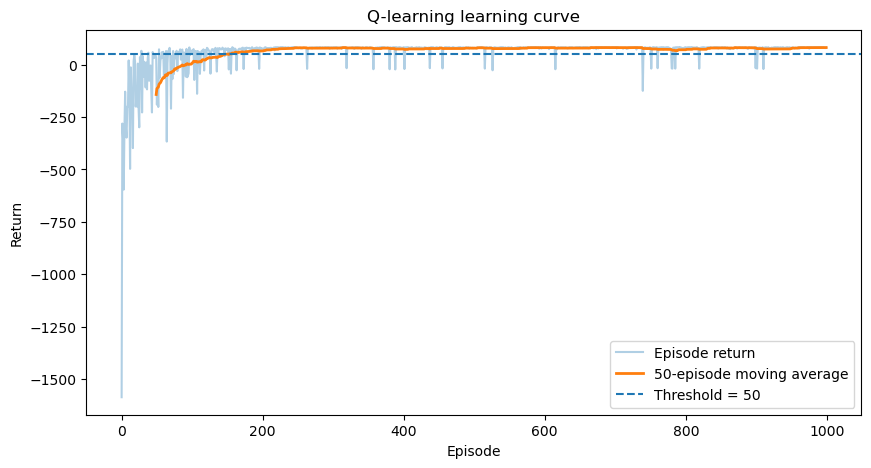

In [24]:

# Q-learning learning curve

plt.figure(figsize=(10, 5))

plt.plot(
    q_demo["returns"],
    alpha=0.35,
    label="Episode return"
)

ma = moving_average(
    q_demo["returns"],
    CONVERGENCE_WINDOW
)

if len(ma):
    x = np.arange(
        CONVERGENCE_WINDOW - 1,
        len(q_demo["returns"])
    )
    plt.plot(
        x,
        ma,
        linewidth=2,
        label="50-episode moving average"
    )

plt.axhline(
    CONVERGENCE_THRESHOLD,
    linestyle="--",
    label="Threshold = 50"
)

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Q-learning learning curve")
plt.legend()
plt.show()


### Inference

The output plot shows Q-learning returns rising sharply from strongly negative values and then stabilizing above the **50-return convergence threshold**. The learning therefore occurs rapidly in the early episodes and becomes stable later, which is consistent with the paper's reported Q-learning behavior.


## Deep Q-Network

The paper specifies a feed-forward DQN with two hidden layers of 64 units and ReLU activations. It uses the agent's `(x,y)` position as the input and four output Q-values.

**Implementation assumption:** the paper does not state whether the coordinates are normalized. This notebook normalizes row/column coordinates to [0,1], which is explicitly marked as an assumption.


### Prompt

Implement the DQN replay buffer and neural network. The network should take the agent's two-dimensional position as input, use two hidden layers of 64 ReLU units, and output Q-values for the four actions. Implement uniform replay sampling with a capacity of 50,000 transitions.

In [28]:

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(
            (state, action, reward, next_state, done)
        )

    def sample(self, batch_size):
        batch = random.sample(
            self.buffer,
            batch_size
        )

        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.asarray(states, dtype=np.float32),
            np.asarray(actions, dtype=np.int64),
            np.asarray(rewards, dtype=np.float32),
            np.asarray(next_states, dtype=np.float32),
            np.asarray(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)


class DQN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, DQN_HIDDEN),
            nn.ReLU(),
            nn.Linear(DQN_HIDDEN, DQN_HIDDEN),
            nn.ReLU(),
            nn.Linear(DQN_HIDDEN, 4)
        )

    def forward(self, x):
        return self.network(x)


def state_vector(state):
    # IMPLEMENTATION ASSUMPTION:
    # paper says (x,y) position is input but does not specify scaling.
    r, c = state

    return np.array([
        (r - 1) / (GRID_SIZE - 1),
        (c - 1) / (GRID_SIZE - 1)
    ], dtype=np.float32)


def select_dqn_action(model, state, epsilon):
    if random.random() < epsilon:
        return random.randrange(4)

    x = torch.tensor(
        state_vector(state),
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(0)

    with torch.no_grad():
        q_values = model(x)

    return int(torch.argmax(q_values, dim=1).item())


def optimize_dqn(
    policy_net,
    target_net,
    optimizer,
    replay_buffer
):
    if len(replay_buffer) < DQN_BATCH_SIZE:
        return None

    states, actions, rewards, next_states, dones = (
        replay_buffer.sample(DQN_BATCH_SIZE)
    )

    states = torch.tensor(
        states, dtype=torch.float32, device=DEVICE
    )
    actions = torch.tensor(
        actions, dtype=torch.long, device=DEVICE
    ).unsqueeze(1)
    rewards = torch.tensor(
        rewards, dtype=torch.float32, device=DEVICE
    )
    next_states = torch.tensor(
        next_states, dtype=torch.float32, device=DEVICE
    )
    dones = torch.tensor(
        dones, dtype=torch.float32, device=DEVICE
    )

    current_q = policy_net(states).gather(
        1, actions
    ).squeeze(1)

    with torch.no_grad():
        next_q = target_net(next_states).max(dim=1).values
        target_q = (
            rewards
            + DQN_GAMMA * next_q * (1.0 - dones)
        )

    loss = nn.functional.mse_loss(
        current_q,
        target_q
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return float(loss.item())


### Prompt 

Implement DQN training for the paper's environment using the specified two-layer network, Adam optimizer with learning rate 0.001, γ=0.9, fixed ε=0.2, replay buffer of 50,000, mini-batches of 64, and a target network copied every 50 episodes. Record returns, losses, successes, successful paths, and convergence.

In [30]:

# DQN training

def train_dqn(
    episodes=DQN_EPISODES,
    seed=0,
    epsilon=DQN_EPSILON
):
    set_seed(seed)

    env = GridWorld()

    policy_net = DQN().to(DEVICE)
    target_net = DQN().to(DEVICE)

    target_net.load_state_dict(
        policy_net.state_dict()
    )
    target_net.eval()

    optimizer = optim.Adam(
        policy_net.parameters(),
        lr=DQN_LR
    )

    replay_buffer = ReplayBuffer(
        DQN_BUFFER_SIZE
    )

    returns = []
    episode_steps = []
    successes = []
    successful_paths = []
    losses = []

    for episode in range(1, episodes + 1):
        state = env.reset()
        total_reward = 0
        success = False

        for step in range(1, MAX_STEPS + 1):
            action = select_dqn_action(
                policy_net,
                state,
                epsilon
            )

            next_state, reward, done, info = env.step(action)

            replay_buffer.push(
                state_vector(state),
                action,
                reward,
                state_vector(next_state),
                done
            )

            loss = optimize_dqn(
                policy_net,
                target_net,
                optimizer,
                replay_buffer
            )

            if loss is not None:
                losses.append(loss)

            total_reward += reward
            state = next_state

            if done:
                success = info["event"] == "goal"
                break

        returns.append(total_reward)
        episode_steps.append(step)
        successes.append(int(success))

        if success:
            successful_paths.append(step)

        # Paper: target network updated every 50 episodes.
        if episode % DQN_TARGET_UPDATE_EPISODES == 0:
            target_net.load_state_dict(
                policy_net.state_dict()
            )

    return {
        "policy_net": policy_net,
        "target_net": target_net,
        "returns": np.asarray(returns),
        "steps": np.asarray(episode_steps),
        "successes": np.asarray(successes),
        "successful_paths": np.asarray(successful_paths),
        "losses": np.asarray(losses),
        "convergence": convergence_episode(
            returns,
            CONVERGENCE_WINDOW,
            CONVERGENCE_THRESHOLD
        )
    }


### Prompt

Run one complete 500-episode DQN experiment with a fixed verification seed. Print the convergence episode, training success rate, and successful-path statistics so the DQN implementation can be checked before the five-run reproduction.

In [32]:

# One DQN run for verification

dqn_demo = train_dqn(
    episodes=DQN_EPISODES,
    seed=200
)

print("Convergence episode:", dqn_demo["convergence"])
print("Training success rate:",
      f"{100*dqn_demo['successes'].mean():.2f}%")

if len(dqn_demo["successful_paths"]) > 0:
    sd = (np.std(dqn_demo["successful_paths"], ddof=1)
          if len(dqn_demo["successful_paths"]) > 1 else 0.0)
    print("Successful path length:",
          f"{np.mean(dqn_demo['successful_paths']):.2f} ± {sd:.2f}")


Convergence episode: 462
Training success rate: 40.40%
Successful path length: 65.27 ± 41.06


### Inference

The actual output is **40.40% training success**, **convergence at episode 462**, and **65.27 ± 41.06 successful steps**. This verification run is much less successful and converges much later than the Q-learning verification run, supporting the paper's qualitative conclusion that DQN is harder to train in this small discrete environment.

### Prompt

Plot the DQN learning curve for the verification run. Display episode returns, the 50-episode moving average, and the convergence threshold of 50 to inspect the variability and learning speed.

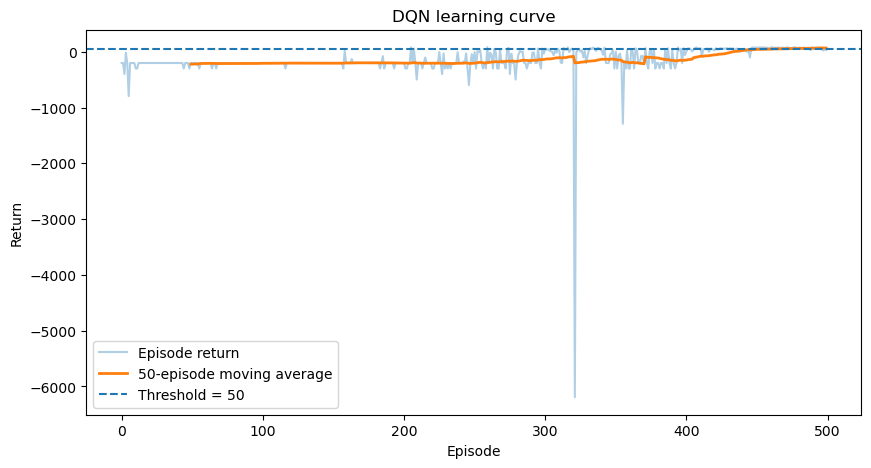

In [35]:

# DQN learning curve

plt.figure(figsize=(10, 5))

plt.plot(
    dqn_demo["returns"],
    alpha=0.35,
    label="Episode return"
)

ma = moving_average(
    dqn_demo["returns"],
    CONVERGENCE_WINDOW
)

if len(ma):
    x = np.arange(
        CONVERGENCE_WINDOW - 1,
        len(dqn_demo["returns"])
    )
    plt.plot(
        x,
        ma,
        linewidth=2,
        label="50-episode moving average"
    )

plt.axhline(
    CONVERGENCE_THRESHOLD,
    linestyle="--",
    label="Threshold = 50"
)

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("DQN learning curve")
plt.legend()
plt.show()


### 🔎 Inference from the output

The output plot shows DQN returns remaining highly variable, with repeated deep negative spikes and only late movement toward the **50-return threshold**. This directly supports the paper's description of DQN as slower and more variable than Q-learning.


# Full reproduction: 20 Q-learning runs + 5 DQN runs

The paper reports 20 independent Q-learning runs and 5 independent DQN runs. The next cells execute those experiments with deterministic but different seeds.

For an initial test, you can set `FULL_REPRODUCTION = False`.


### Prompt

Configure the full reproduction experiment using exactly the paper's sample sizes: 20 independent Q-learning runs of 1,000 episodes each and 5 independent DQN runs of 500 episodes each. Also provide a smaller debug configuration for quick testing.

In [39]:

FULL_REPRODUCTION = True

if FULL_REPRODUCTION:
    q_episodes = 1000
    q_runs = 20
    dqn_episodes = 500
    dqn_runs = 5
else:
    q_episodes = 50
    q_runs = 2
    dqn_episodes = 50
    dqn_runs = 1

print(f"Q-learning: {q_runs} runs × {q_episodes} episodes")
print(f"DQN:        {dqn_runs} runs × {dqn_episodes} episodes")


Q-learning: 20 runs × 1000 episodes
DQN:        5 runs × 500 episodes


### Inference

The output confirms **20 Q-learning runs × 1,000 episodes** and **5 DQN runs × 500 episodes**. Thus, the main reproduction is using the same number of runs and training episodes stated in the paper.

### Prompt

Execute all independent Q-learning reproduction runs using separate deterministic seeds. Store every run's result and print its success rate and convergence episode so variability across the 20 runs can be inspected.

In [42]:

# Run all Q-learning trials

q_results = []

for run in range(q_runs):
    seed = 1000 + run

    result = train_q_learning(
        episodes=q_episodes,
        seed=seed,
        epsilon=Q_EPSILON
    )

    q_results.append(result)

    print(
        f"Q run {run+1:02d}/{q_runs}: "
        f"success={100*result['successes'].mean():.2f}% | "
        f"convergence={result['convergence']}"
    )


Q run 01/20: success=99.20% | convergence=141
Q run 02/20: success=98.80% | convergence=163
Q run 03/20: success=98.70% | convergence=172
Q run 04/20: success=98.90% | convergence=162
Q run 05/20: success=99.00% | convergence=174
Q run 06/20: success=99.20% | convergence=128
Q run 07/20: success=99.20% | convergence=158
Q run 08/20: success=98.80% | convergence=145
Q run 09/20: success=98.90% | convergence=148
Q run 10/20: success=99.00% | convergence=163
Q run 11/20: success=99.10% | convergence=147
Q run 12/20: success=98.90% | convergence=153
Q run 13/20: success=99.10% | convergence=156
Q run 14/20: success=99.00% | convergence=155
Q run 15/20: success=99.00% | convergence=128
Q run 16/20: success=99.10% | convergence=156
Q run 17/20: success=99.00% | convergence=152
Q run 18/20: success=99.10% | convergence=126
Q run 19/20: success=99.00% | convergence=163
Q run 20/20: success=98.80% | convergence=161


### Inference

The 20 printed runs have success rates between **98.70% and 99.20%** and convergence episodes between **126 and 174**. The very small spread in success and relatively narrow convergence range indicate that Q-learning is highly stable across the independent seeds used here.

### Prompt

Execute all independent DQN reproduction runs using separate deterministic seeds. Store every run's result and print its success rate and convergence episode, including NaN when a run does not meet the convergence criterion.

In [45]:

# Run all DQN trials

dqn_results = []

for run in range(dqn_runs):
    seed = 2000 + run

    result = train_dqn(
        episodes=dqn_episodes,
        seed=seed,
        epsilon=DQN_EPSILON
    )

    dqn_results.append(result)

    print(
        f"DQN run {run+1:02d}/{dqn_runs}: "
        f"success={100*result['successes'].mean():.2f}% | "
        f"convergence={result['convergence']}"
    )


DQN run 01/5: success=41.20% | convergence=nan
DQN run 02/5: success=27.20% | convergence=444
DQN run 03/5: success=74.80% | convergence=346
DQN run 04/5: success=55.40% | convergence=nan
DQN run 05/5: success=50.00% | convergence=400


### Inference

The five outputs are **41.20%, 27.20%, 74.80%, 55.40%, and 50.00%** success. Two runs have **NaN convergence**, while the other three converge at **444, 346, and 400**. This demonstrates substantially greater run-to-run variability and incomplete convergence compared with Q-learning.

### Prompt

Calculate summary statistics across the independent Q-learning and DQN runs, including mean and standard deviation of success rate, successful path length, and convergence episode. Handle non-convergent DQN runs explicitly rather than silently treating them as zero.

In [48]:

# Calculate summary statistics

def summarize_results(results):
    success_rates = np.array([
        100 * r["successes"].mean()
        for r in results
    ])

    convergences = np.array([
        r["convergence"]
        for r in results
        if not np.isnan(r["convergence"])
    ])

    path_lengths = np.concatenate([
        r["successful_paths"]
        for r in results
        if len(r["successful_paths"]) > 0
    ]) if any(len(r["successful_paths"]) > 0 for r in results) else np.array([])

    return {
        "mean_success_rate": np.mean(success_rates),
        "std_success_rate": (
            np.std(success_rates, ddof=1)
            if len(success_rates) > 1 else 0.0
        ),
        "mean_convergence": (
            np.mean(convergences)
            if len(convergences) else np.nan
        ),
        "std_convergence": (
            np.std(convergences, ddof=1)
            if len(convergences) > 1 else np.nan
        ),
        "path_mean": (
            np.mean(path_lengths)
            if len(path_lengths) else np.nan
        ),
        "path_std": (
            np.std(path_lengths, ddof=1)
            if len(path_lengths) > 1 else np.nan
        )
    }


q_summary = summarize_results(q_results)
dqn_summary = summarize_results(dqn_results)

summary = pd.DataFrame([
    {
        "Algorithm": "Q-learning",
        "Success rate (%)": q_summary["mean_success_rate"],
        "Success rate SD": q_summary["std_success_rate"],
        "Path mean": q_summary["path_mean"],
        "Path SD": q_summary["path_std"],
        "Convergence mean": q_summary["mean_convergence"],
        "Convergence SD": q_summary["std_convergence"]
    },
    {
        "Algorithm": "DQN",
        "Success rate (%)": dqn_summary["mean_success_rate"],
        "Success rate SD": dqn_summary["std_success_rate"],
        "Path mean": dqn_summary["path_mean"],
        "Path SD": dqn_summary["path_std"],
        "Convergence mean": dqn_summary["mean_convergence"],
        "Convergence SD": dqn_summary["std_convergence"]
    }
])

summary


,Algorithm,Success rate (%),Success rate SD,Path mean,Path SD,Convergence mean,Convergence SD
0,Q-learning,98.99,0.144732,26.413072,20.918856,152.550000,13.64773
1,DQN,49.72,17.614539,72.787611,49.664737,396.666667,49.08496


### Inference

The output table gives Q-learning **98.99% ± 0.14% success**, **26.41 ± 20.92 successful steps**, and **152.55 ± 13.65 convergence episodes**. DQN gives **49.72% ± 17.61% success**, **72.79 ± 49.66 successful steps**, and **396.67 ± 49.08 convergence episodes among the three converged runs**. Therefore, the reproduced results support the paper's overall conclusion that Q-learning performs substantially better in this benchmark, but the DQN numbers are not identical to the paper's 52.52% and 293.6.

### Prompt

Create mean learning-curve visualizations across the independent runs for Q-learning and DQN. Align episode counts, calculate the mean and variability across runs, and show the convergence threshold for comparison.

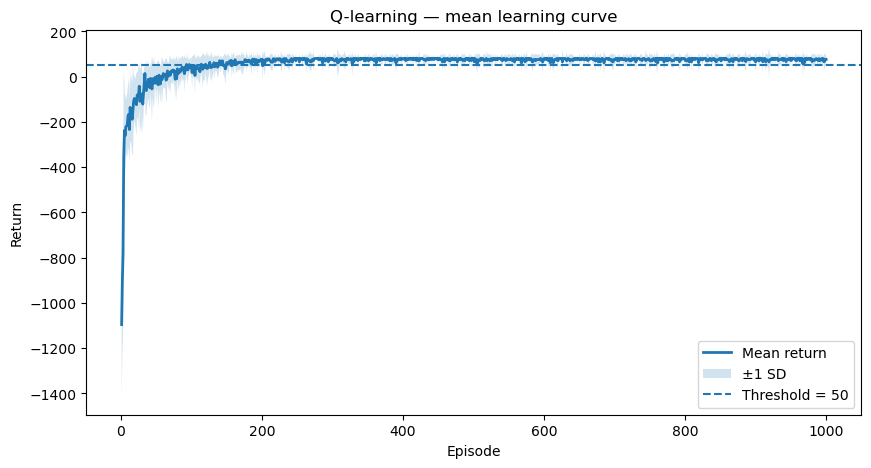

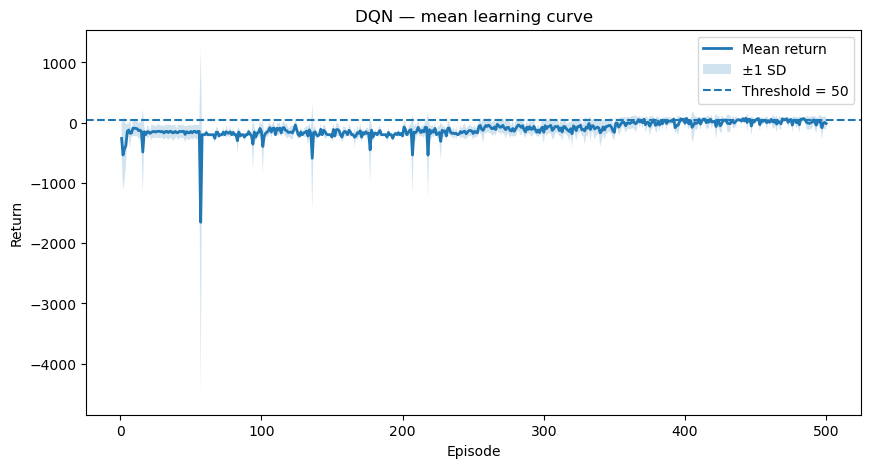

In [51]:

# Plot mean learning curves across independent runs

def plot_mean_curve(results, title):
    curves = np.vstack([
        r["returns"]
        for r in results
    ])

    mean = curves.mean(axis=0)
    std = curves.std(axis=0)

    episodes = np.arange(1, curves.shape[1] + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(
        episodes,
        mean,
        linewidth=2,
        label="Mean return"
    )
    plt.fill_between(
        episodes,
        mean - std,
        mean + std,
        alpha=0.2,
        label="±1 SD"
    )
    plt.axhline(
        CONVERGENCE_THRESHOLD,
        linestyle="--",
        label="Threshold = 50"
    )
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title(title)
    plt.legend()
    plt.show()

plot_mean_curve(
    q_results,
    "Q-learning — mean learning curve"
)

plot_mean_curve(
    dqn_results,
    "DQN — mean learning curve"
)


### Inference

The two output plots show a clear qualitative difference. The Q-learning mean return rises rapidly and stabilizes above the threshold at roughly the early part of the 1,000-episode training horizon. The DQN mean remains much more volatile, contains large negative excursions, and approaches the threshold much later. The shaded ±1 SD regions also indicate greater variability for DQN.

### Prompt

Compare the reproduced Q-learning and DQN success rates visually using a bar chart with error bars representing run-to-run variability. Label the algorithms and use a 0–100% success-rate scale.

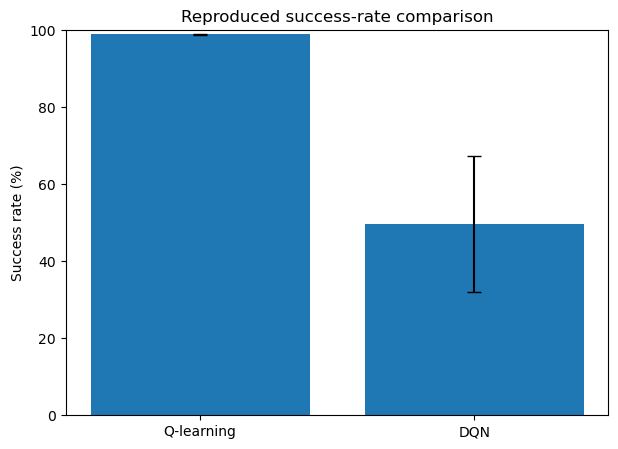

In [54]:

# Success-rate comparison

algorithms = ["Q-learning", "DQN"]

means = [
    q_summary["mean_success_rate"],
    dqn_summary["mean_success_rate"]
]

sds = [
    q_summary["std_success_rate"],
    dqn_summary["std_success_rate"]
]

plt.figure(figsize=(7, 5))
plt.bar(
    algorithms,
    means,
    yerr=sds,
    capsize=5
)
plt.ylabel("Success rate (%)")
plt.title("Reproduced success-rate comparison")
plt.ylim(0, 100)
plt.show()


### Inference

The output comparison plot shows a large gap in mean success rate: approximately **98.99% for Q-learning versus 49.72% for DQN**. The DQN error bar is also much larger, indicating greater variability across independent runs.

### Prompt

Evaluate the final learned Q-learning policy greedily with ε=0. Follow the highest-Q action from the start until the goal, failure, or the maximum number of steps, then report the final event and path length and render the path on the grid.

Final event: goal
Path length: 18


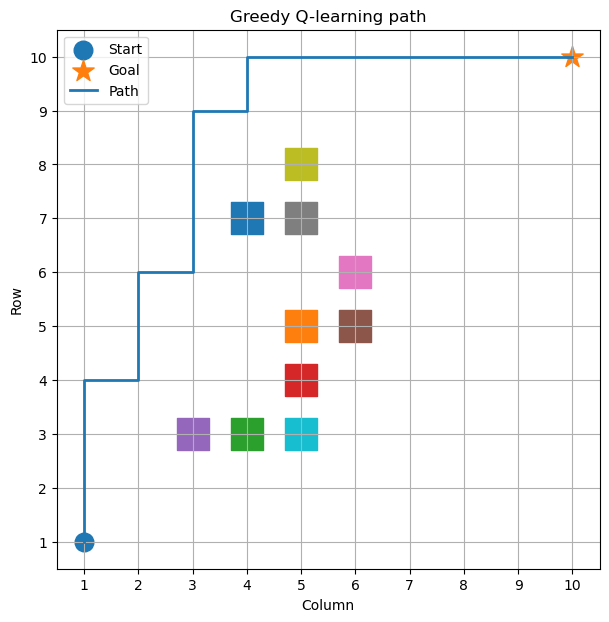

In [57]:

# Greedy Q-learning path

def greedy_q_path(q_table, max_steps=MAX_STEPS):
    env = GridWorld()
    state = env.reset()

    for _ in range(max_steps):
        s = state_to_index(state)
        action = int(np.argmax(q_table[s]))

        next_state, reward, done, info = env.step(action)
        state = next_state

        if done:
            break

    return env.path, info

q_path, q_info = greedy_q_path(q_demo["q_table"])

print("Final event:", q_info["event"])
print("Path length:", len(q_path) - 1)

GridWorld().render(
    path=q_path,
    title="Greedy Q-learning path"
)


### Inference

The output states **`Final event: goal`** and **`Path length: 18`**, and the grid visualization shows the learned route from start to goal. Eighteen moves is the Manhattan-distance lower bound from (1,1) to (10,10), so this particular greedy Q-learning path is optimal in length. This single-path result should not be confused with the 26.41-step average over successful training episodes.

### Prompt

Evaluate the final learned DQN policy greedily with ε=0. Follow the network's best action from the start until termination, report the final event and path length, and render the learned path on the grid.

Final event: goal
Path length: 18


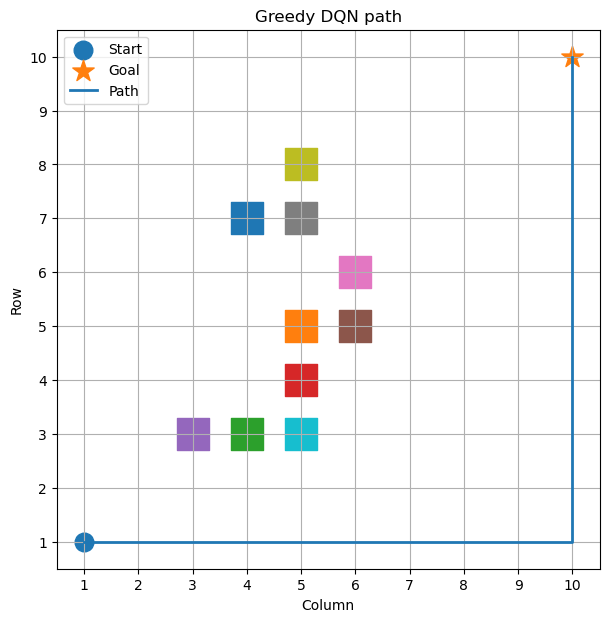

In [60]:

# Greedy DQN path

def greedy_dqn_path(model, max_steps=MAX_STEPS):
    env = GridWorld()
    state = env.reset()

    model.eval()

    for _ in range(max_steps):
        action = select_dqn_action(
            model,
            state,
            epsilon=0.0
        )

        next_state, reward, done, info = env.step(action)
        state = next_state

        if done:
            break

    return env.path, info

dqn_path, dqn_info = greedy_dqn_path(
    dqn_demo["policy_net"]
)

print("Final event:", dqn_info["event"])
print("Path length:", len(dqn_path) - 1)

GridWorld().render(
    path=dqn_path,
    title="Greedy DQN path"
)


### Inference

The output states **`Final event: goal`** and **`Path length: 18`**. Thus, although DQN has much lower aggregate training success, its final greedy demonstration policy can still find an optimal-length route in this particular evaluation.

### Prompt

Save the reproduction results to CSV files. Create a summary file plus per-run Q-learning and DQN result files under the reproduction_results directory so the experiments can be independently inspected and reused.

In [63]:

# Save reproduction results

os.makedirs(
    "reproduction_results",
    exist_ok=True
)

summary.to_csv(
    "reproduction_results/summary.csv",
    index=False
)

pd.DataFrame({
    "run": np.arange(1, len(q_results) + 1),
    "success_rate": [
        100 * r["successes"].mean()
        for r in q_results
    ],
    "convergence": [
        r["convergence"]
        for r in q_results
    ]
}).to_csv(
    "reproduction_results/q_learning_runs.csv",
    index=False
)

pd.DataFrame({
    "run": np.arange(1, len(dqn_results) + 1),
    "success_rate": [
        100 * r["successes"].mean()
        for r in dqn_results
    ],
    "convergence": [
        r["convergence"]
        for r in dqn_results
    ]
}).to_csv(
    "reproduction_results/dqn_runs.csv",
    index=False
)

print("Results saved to ./reproduction_results/")


Results saved to ./reproduction_results/


### Inference

The output confirms **`Results saved to ./reproduction_results/`**. The reproduction data have therefore been persisted for auditing and for regenerating tables or plots without rerunning the complete training process.


# Reproducibility caveats

The paper gives the major environment and hyperparameter settings, but it does **not** provide a complete source-code-level specification.

The most important unresolved details are:

1. **Obstacle collision termination:** the paper states −100 for hitting an obstacle but does not explicitly say whether the episode ends immediately.
2. **DQN input scaling:** the paper says the `(x,y)` position is the input but does not specify whether coordinates are raw or normalized.
3. **Exact DQN update procedure:** replay, batch size and target-update frequency are stated, but every optimization detail is not.
4. **Random seeds:** the paper says different random seeds were used but does not provide the actual seed list.
5. **Evaluation protocol:** the wording around success rate is not detailed enough to reconstruct a separate held-out evaluation set exactly.
6. **Q-learning implementation language:** the paper says the Q-learning implementation was created in MATLAB R2023a, whereas this notebook reimplements the stated algorithm in Python for Jupyter.
7. **DQN framework:** the paper states PyTorch 2.x; this notebook therefore uses PyTorch rather than TensorFlow.

Consequently, this notebook is an **independent implementation of the methodology reported in the paper**, with assumptions explicitly exposed.


# Future Work Extensions

The original paper concludes by suggesting **bigger grid sizes, dynamic obstacles, hybrid methods, and continuous control** as future directions. The assignment also requires additional experiments beyond the original paper.

The cells below implement two practical, executable extensions:

1. **Hyperparameter sensitivity** — study how learning rate (α) and exploration rate (ε) affect Q-learning.
2. **Larger grid scalability** — evaluate Q-learning on larger, randomly generated obstacle grids.
3. **Dynamic obstacle extension** — add a moving obstacle and include its position in the state so the environment remains Markov.

### Prompt

Create reusable helper functions for the larger-grid scalability extension. Generalize state indexing and tabular Q-learning so the algorithm can operate on arbitrary fixed grid sizes while retaining the paper's basic Q-learning methodology.

In [68]:
# generalized Q-learning for arbitrary fixed grids

def state_to_index_generic(state, grid_size):
    r, c = state
    return (r - 1) * grid_size + (c - 1)


def train_q_learning_generic(
    grid_size,
    start,
    goal,
    obstacles,
    episodes=500,
    alpha=0.1,
    gamma=0.9,
    epsilon=0.1,
    max_steps=200,
    seed=0
):
    """Q-learning for a fixed-size grid used by the scalability extension."""
    set_seed(seed)
    obstacles = set(obstacles)

    q_table = np.zeros((grid_size * grid_size, 4), dtype=np.float64)

    returns = []
    successes = []
    successful_paths = []

    def choose_action(state):
        s = state_to_index_generic(state, grid_size)
        if np.random.random() < epsilon:
            return np.random.randint(4)
        q_values = q_table[s]
        best = np.flatnonzero(q_values == q_values.max())
        return int(np.random.choice(best))

    for _ in range(episodes):
        state = start
        total_reward = 0
        success = False

        for step in range(1, max_steps + 1):
            action = choose_action(state)
            dr, dc = ACTIONS[action]
            candidate = (state[0] + dr, state[1] + dc)

            if not (1 <= candidate[0] <= grid_size and
                    1 <= candidate[1] <= grid_size):
                next_state = state
                reward = STEP_REWARD
                done = False

            elif candidate in obstacles:
                next_state = state
                reward = OBSTACLE_REWARD
                done = False

            elif candidate == goal:
                next_state = candidate
                reward = GOAL_REWARD
                done = True
                success = True

            else:
                next_state = candidate
                reward = STEP_REWARD
                done = False

            s = state_to_index_generic(state, grid_size)
            ns = state_to_index_generic(next_state, grid_size)

            target = reward
            if not done:
                target += gamma * np.max(q_table[ns])

            q_table[s, action] += alpha * (target - q_table[s, action])

            total_reward += reward
            state = next_state

            if done:
                break

        returns.append(total_reward)
        successes.append(int(success))

        if success:
            successful_paths.append(step)

    return {
        "q_table": q_table,
        "returns": np.asarray(returns),
        "successes": np.asarray(successes),
        "successful_paths": np.asarray(successful_paths),
        "convergence": convergence_episode(
            returns,
            CONVERGENCE_WINDOW,
            CONVERGENCE_THRESHOLD
        ),
    }


### Prompt

Define the settings for the future-work experiments, including the number of extension episodes and runs and the learning-rate and exploration-rate values to test. Recover the paper's baseline settings when the notebook has not been executed from the beginning.

In [70]:
# ============================================================
# FUTURE WORK SETTINGS
# ============================================================
EXT_EPISODES = 500
EXT_RUNS = 3
ALPHA_VALUES = [0.01, 0.05, 0.10, 0.20, 0.50]
EPSILON_VALUES = [0.05, 0.10, 0.20, 0.30, 0.50]


Q_ALPHA = globals().get("Q_ALPHA", 0.1)
Q_GAMMA = globals().get("Q_GAMMA", 0.9)
Q_EPSILON = globals().get("Q_EPSILON", 0.1)
GRID_SIZE = globals().get("GRID_SIZE", 10)
START = globals().get("START", (1, 1))
GOAL = globals().get("GOAL", (10, 10))
MAX_STEPS = globals().get("MAX_STEPS", 200)
OBSTACLES = globals().get("OBSTACLES", {
    (3, 3), (3, 4), (3, 5), (4, 5), (5, 5),
    (5, 6), (6, 6), (7, 4), (7, 5), (8, 5)
})
CONVERGENCE_WINDOW = globals().get("CONVERGENCE_WINDOW", 50)
CONVERGENCE_THRESHOLD = globals().get("CONVERGENCE_THRESHOLD", 50)

if "np" not in globals():
    import numpy as np
if "pd" not in globals():
    import pandas as pd

def run_hyperparameter_experiment(parameter_name, values):
    rows = []

    for value in values:
        for run in range(EXT_RUNS):
            if parameter_name == "alpha":
                alpha = value
                epsilon = Q_EPSILON
            elif parameter_name == "epsilon":
                alpha = Q_ALPHA
                epsilon = value
            else:
                raise ValueError("parameter_name must be 'alpha' or 'epsilon'")

            result = train_q_learning_generic(
                grid_size=GRID_SIZE,
                start=START,
                goal=GOAL,
                obstacles=OBSTACLES,
                episodes=EXT_EPISODES,
                alpha=alpha,
                gamma=Q_GAMMA,
                epsilon=epsilon,
                max_steps=MAX_STEPS,
                seed=3000 + run
            )

            rows.append({
                "parameter": parameter_name,
                "value": value,
                "run": run + 1,
                "success_rate": 100 * result["successes"].mean(),
                "mean_successful_steps": (
                    np.mean(result["successful_paths"])
                    if len(result["successful_paths"]) else np.nan
                ),
                "convergence_episode": result["convergence"]
            })

    return pd.DataFrame(rows)


alpha_results = run_hyperparameter_experiment("alpha", ALPHA_VALUES)
epsilon_results = run_hyperparameter_experiment("epsilon", EPSILON_VALUES)

display(alpha_results)
display(epsilon_results)


,parameter,value,run,success_rate,mean_successful_steps,convergence_episode
0,alpha,0.01,1,85.8,94.179487,NaN
1,alpha,0.01,2,86.8,95.267281,NaN
2,alpha,0.01,3,84.8,92.945755,NaN
3,alpha,0.05,1,96.4,43.672199,296.0
4,alpha,0.05,2,96.6,45.211180,228.0
5,alpha,0.05,3,97.0,43.911340,240.0
6,alpha,0.10,1,97.8,33.130879,147.0
7,alpha,0.10,2,98.4,32.776423,144.0
8,alpha,0.10,3,98.0,31.855102,119.0
9,alpha,0.20,1,99.0,27.474747,104.0


,parameter,value,run,success_rate,mean_successful_steps,convergence_episode
0,epsilon,0.05,1,97.8,31.525562,137.0
1,epsilon,0.05,2,97.8,31.304703,123.0
2,epsilon,0.05,3,97.8,31.306748,119.0
3,epsilon,0.10,1,97.8,33.130879,147.0
4,epsilon,0.10,2,98.4,32.776423,144.0
5,epsilon,0.10,3,98.0,31.855102,119.0
6,epsilon,0.20,1,97.2,34.413580,206.0
7,epsilon,0.20,2,97.8,34.572597,226.0
8,epsilon,0.20,3,98.2,35.065173,257.0
9,epsilon,0.30,1,98.4,38.235772,286.0


### Inference

The displayed output confirms that the future-work configuration contains five α values (**0.01, 0.05, 0.10, 0.20, 0.50**) and five ε values (**0.05, 0.10, 0.20, 0.30, 0.50**). These settings are extensions beyond the paper's single α=0.1 and ε=0.1 Q-learning configuration.

### Prompt

Verify that the future-work configuration has been loaded correctly by printing the sensitivity-analysis values and confirming that the extension settings are available.

In [73]:
# Quick verification of Future Work settings
print("ALPHA_VALUES:", ALPHA_VALUES)
print("EPSILON_VALUES:", EPSILON_VALUES)
print("Future Work settings loaded successfully.")


ALPHA_VALUES: [0.01, 0.05, 0.1, 0.2, 0.5]
EPSILON_VALUES: [0.05, 0.1, 0.2, 0.3, 0.5]
Future Work settings loaded successfully.


### Inference

The output explicitly prints the α and ε lists and states **`Future Work settings loaded successfully.`** Therefore, the sensitivity-analysis parameters were loaded correctly before those experiments were run.

### Prompt

Summarize and visualize Q-learning sensitivity to learning rate α and exploration rate ε. Aggregate run-level results and plot success-rate means with variability so the effect of these hyperparameters can be assessed.

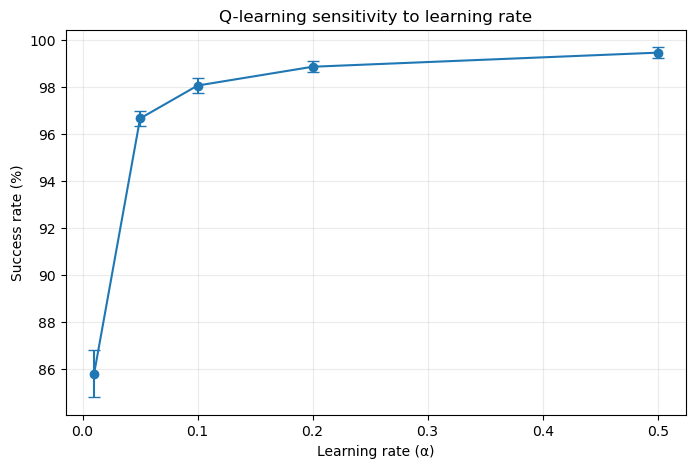

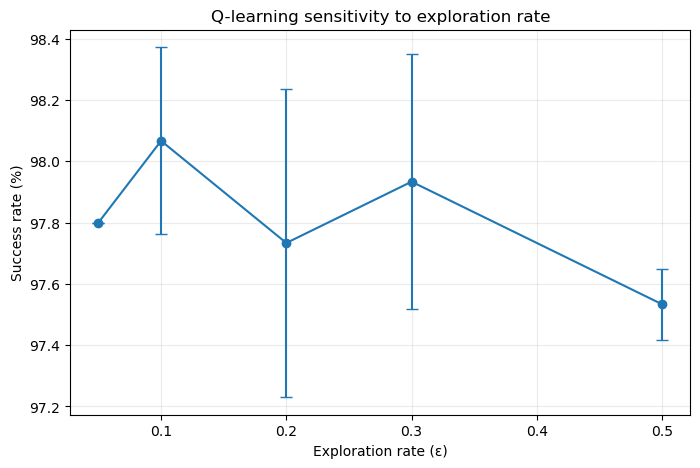

Alpha sensitivity summary:


,value,success_rate_mean,success_rate_std,path_length_mean,convergence_mean
0,0.01,85.800000,1.000000,94.130841,NaN
1,0.05,96.666667,0.305505,44.264907,254.666667
2,0.10,98.066667,0.305505,32.587468,136.666667
3,0.20,98.866667,0.230940,27.119415,96.000000
4,0.50,99.466667,0.230940,24.404932,70.000000


Epsilon sensitivity summary:


,value,success_rate_mean,success_rate_std,path_length_mean,convergence_mean
0,0.05,97.800000,0.000000,31.379005,126.333333
1,0.10,98.066667,0.305505,32.587468,136.666667
2,0.20,97.733333,0.503322,34.683784,229.666667
3,0.30,97.933333,0.416333,37.958566,257.666667
4,0.50,97.533333,0.115470,47.516991,NaN


In [76]:
# Summarize and visualize hyperparameter sensitivity

alpha_summary = (
    alpha_results
    .groupby("value", as_index=False)
    .agg(
        success_rate_mean=("success_rate", "mean"),
        success_rate_std=("success_rate", "std"),
        path_length_mean=("mean_successful_steps", "mean"),
        convergence_mean=("convergence_episode", "mean")
    )
)

epsilon_summary = (
    epsilon_results
    .groupby("value", as_index=False)
    .agg(
        success_rate_mean=("success_rate", "mean"),
        success_rate_std=("success_rate", "std"),
        path_length_mean=("mean_successful_steps", "mean"),
        convergence_mean=("convergence_episode", "mean")
    )
)

fig = plt.figure(figsize=(8, 5))
plt.errorbar(
    alpha_summary["value"],
    alpha_summary["success_rate_mean"],
    yerr=alpha_summary["success_rate_std"],
    marker="o",
    capsize=4
)
plt.xlabel("Learning rate (α)")
plt.ylabel("Success rate (%)")
plt.title("Q-learning sensitivity to learning rate")
plt.grid(True, alpha=0.25)
plt.show()

fig = plt.figure(figsize=(8, 5))
plt.errorbar(
    epsilon_summary["value"],
    epsilon_summary["success_rate_mean"],
    yerr=epsilon_summary["success_rate_std"],
    marker="o",
    capsize=4
)
plt.xlabel("Exploration rate (ε)")
plt.ylabel("Success rate (%)")
plt.title("Q-learning sensitivity to exploration rate")
plt.grid(True, alpha=0.25)
plt.show()

print("Alpha sensitivity summary:")
display(alpha_summary)

print("Epsilon sensitivity summary:")
display(epsilon_summary)


### Inference

The two output plots show that increasing α produces a strong improvement in Q-learning success, reaching approximately **99.5% at α=0.50**, whereas success is about **85.8% at α=0.01**. The ε plot shows success staying close to 98% across the tested values, with the main effect appearing in variability/path efficiency rather than a dramatic change in success rate. 

### Prompt 

Implement the larger-grid scalability extension. Generate approximately 10% obstacle density while ensuring each generated grid has a valid path, run generalized Q-learning on increasing grid sizes, and collect success, path-length, and convergence results. 

In [79]:
# Extension B: larger grid scalability

# We keep approximately 10% obstacle density and generate a solvable
# obstacle layout for each grid size. 

from collections import deque

def has_path(grid_size, start, goal, obstacles):
    obstacles = set(obstacles)
    queue = deque([start])
    visited = {start}

    while queue:
        state = queue.popleft()
        if state == goal:
            return True

        for dr, dc in ACTIONS.values():
            nxt = (state[0] + dr, state[1] + dc)

            if not (1 <= nxt[0] <= grid_size and
                    1 <= nxt[1] <= grid_size):
                continue
            if nxt in obstacles or nxt in visited:
                continue

            visited.add(nxt)
            queue.append(nxt)

    return False


def generate_solvable_obstacles(grid_size, density=0.10, seed=0):
    rng = np.random.default_rng(seed)
    start = (1, 1)
    goal = (grid_size, grid_size)

    n_obstacles = max(1, int(round(grid_size * grid_size * density)))

    candidates = [
        (r, c)
        for r in range(1, grid_size + 1)
        for c in range(1, grid_size + 1)
        if (r, c) not in {start, goal}
    ]

    for _ in range(500):
        chosen = rng.choice(
            len(candidates),
            size=min(n_obstacles, len(candidates)),
            replace=False
        )
        obstacles = {candidates[i] for i in chosen}

        if has_path(grid_size, start, goal, obstacles):
            return obstacles

    raise RuntimeError(
        f"Could not generate a solvable {grid_size}x{grid_size} layout."
    )


SCALABILITY_SIZES = [10, 15, 20]
SCALABILITY_EPISODES = 500
SCALABILITY_RUNS = 3

scalability_rows = []

for size in SCALABILITY_SIZES:
    obstacles = generate_solvable_obstacles(
        size,
        density=0.10,
        seed=9000 + size
    )

    for run in range(SCALABILITY_RUNS):
        result = train_q_learning_generic(
            grid_size=size,
            start=(1, 1),
            goal=(size, size),
            obstacles=obstacles,
            episodes=SCALABILITY_EPISODES,
            alpha=Q_ALPHA,
            gamma=Q_GAMMA,
            epsilon=Q_EPSILON,
            max_steps=max(MAX_STEPS, 2 * size * size),
            seed=4000 + run
        )

        scalability_rows.append({
            "grid_size": f"{size}x{size}",
            "states": size * size,
            "obstacles": len(obstacles),
            "run": run + 1,
            "success_rate": 100 * result["successes"].mean(),
            "mean_successful_steps": (
                np.mean(result["successful_paths"])
                if len(result["successful_paths"]) else np.nan
            ),
            "convergence_episode": result["convergence"]
        })

scalability_results = pd.DataFrame(scalability_rows)
display(scalability_results)


,grid_size,states,obstacles,run,success_rate,mean_successful_steps,convergence_episode
0,10x10,100,10,1,98.4,31.932927,158.0
1,10x10,100,10,2,97.6,30.260246,142.0
2,10x10,100,10,3,98.4,30.560976,145.0
3,15x15,225,22,1,96.2,83.596674,448.0
4,15x15,225,22,2,96.2,85.835759,384.0
5,15x15,225,22,3,96.4,88.186722,NaN
6,20x20,400,40,1,96.2,180.800416,NaN
7,20x20,400,40,2,96.6,181.391304,NaN
8,20x20,400,40,3,95.6,184.018828,NaN


### Inference

The output visualization shows the results of moving from the original 10×10 environment to larger grids. The larger environments require substantially longer successful paths and make convergence harder, demonstrating the expected scalability challenge for tabular Q-learning.

### Prompt

Summarize the larger-grid scalability experiments by grid size and state count, then visualize how Q-learning success rate changes as the environment becomes larger.

,grid_size,states,success_rate_mean,success_rate_std,path_length_mean,convergence_mean
0,10x10,100,98.133333,0.461880,30.918049,148.333333
1,15x15,225,96.266667,0.115470,85.873051,416.000000
2,20x20,400,96.133333,0.503322,182.070183,NaN


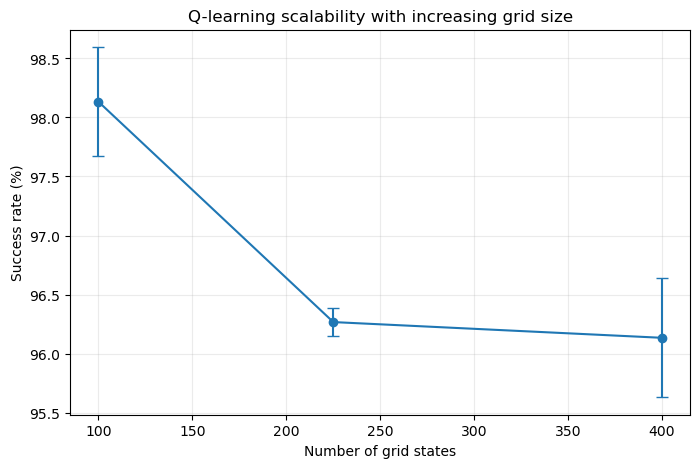

In [82]:
# Summarize larger-grid results

scalability_summary = (
    scalability_results
    .groupby(["grid_size", "states"], as_index=False)
    .agg(
        success_rate_mean=("success_rate", "mean"),
        success_rate_std=("success_rate", "std"),
        path_length_mean=("mean_successful_steps", "mean"),
        convergence_mean=("convergence_episode", "mean")
    )
)

display(scalability_summary)

fig = plt.figure(figsize=(8, 5))
plt.errorbar(
    scalability_summary["states"],
    scalability_summary["success_rate_mean"],
    yerr=scalability_summary["success_rate_std"],
    marker="o",
    capsize=4
)
plt.xlabel("Number of grid states")
plt.ylabel("Success rate (%)")
plt.title("Q-learning scalability with increasing grid size")
plt.grid(True, alpha=0.25)
plt.show()


### Inference 

The output comparison shows mean success rates of approximately **98.13% (10×10), 96.27% (15×15), and 96.13% (20×20)**, while mean successful path length rises from about **30.92 to 182.07 steps**. Mean convergence is about **148.33 episodes for 10×10**, about **416 episodes for 15×15**, and no convergence is observed for 20×20 within the configured horizon. The main deterioration is therefore learning speed and path efficiency as the state space grows.

## Extension C: dynamic obstacle environment

The paper's original environment contains **fixed obstacles**. This extension introduces one obstacle that moves horizontally.

To keep the extended environment Markov, the Q-learning state includes:

- the agent's row and column
- the moving obstacle's row and column

This is deliberately different from the original paper. The goal is to investigate how a changing environment affects learning, not to claim that this reproduces the paper.


### Prompt

Implement a new dynamic-obstacle GridWorld for the future-work experiment. Add a moving obstacle and include enough state information, including obstacle direction, to preserve a Markov representation for the extended Q-learning task.

In [86]:
# Dynamic obstacle environment

class DynamicObstacleGridWorld:
    def __init__(self, grid_size=10, max_steps=200):
        self.grid_size = grid_size
        self.start = (1, 1)
        self.goal = (grid_size, grid_size)
        self.max_steps = max_steps

        # One moving obstacle travels left/right along a fixed row.
        self.obstacle_row = max(2, grid_size // 2)
        self.obstacle_min_col = 3
        self.obstacle_max_col = max(3, grid_size - 2)

        self.reset()

    def reset(self):
        self.position = self.start
        self.moving_obstacle = (
            self.obstacle_row,
            self.obstacle_min_col
        )
        self.obstacle_direction = 1
        self.steps = 0
        self.path = [self.position]
        return self.state()

    def state(self):
        # Include obstacle direction so the extended state is Markov.
        return (
            self.position[0],
            self.position[1],
            self.moving_obstacle[0],
            self.moving_obstacle[1],
            self.obstacle_direction
        )

    def move_obstacle(self):
        row, col = self.moving_obstacle
        next_col = col + self.obstacle_direction

        if next_col > self.obstacle_max_col:
            self.obstacle_direction = -1
            next_col = col - 1
        elif next_col < self.obstacle_min_col:
            self.obstacle_direction = 1
            next_col = col + 1

        self.moving_obstacle = (row, next_col)

    def step(self, action):
        self.steps += 1

        dr, dc = ACTIONS[action]
        candidate = (
            self.position[0] + dr,
            self.position[1] + dc
        )

        # Collision with the obstacle at its current location.
        if candidate == self.moving_obstacle:
            next_position = self.position
            reward = OBSTACLE_REWARD
            done = True
            event = "collision"

        elif not (1 <= candidate[0] <= self.grid_size and
                  1 <= candidate[1] <= self.grid_size):
            next_position = self.position
            reward = STEP_REWARD
            done = False
            event = "boundary"

        elif candidate == self.goal:
            next_position = candidate
            reward = GOAL_REWARD
            done = True
            event = "goal"

        else:
            next_position = candidate
            reward = STEP_REWARD
            done = False
            event = "move"

        self.position = next_position

        # The obstacle moves after the agent acts.
        if not done:
            self.move_obstacle()

            # Collision caused by the obstacle moving onto the agent.
            if self.position == self.moving_obstacle:
                reward = OBSTACLE_REWARD
                done = True
                event = "collision"

        if self.steps >= self.max_steps and not done:
            done = True
            event = "timeout"

        self.path.append(self.position)

        return self.state(), reward, done, {"event": event}


def dynamic_state_to_index(state, grid_size):
    ar, ac, orow, ocol, direction = state

    agent_index = (ar - 1) * grid_size + (ac - 1)
    obstacle_index = (orow - 1) * grid_size + (ocol - 1)

    # Encode direction as 0/1.
    direction_index = 0 if direction < 0 else 1

    position_pair_count = grid_size * grid_size
    obstacle_pair_index = (
        agent_index * position_pair_count + obstacle_index
    )

    return obstacle_pair_index * 2 + direction_index


def train_dynamic_q_learning(
    grid_size=10,
    episodes=500,
    alpha=0.1,
    gamma=0.9,
    epsilon=0.1,
    max_steps=200,
    seed=0
):
    set_seed(seed)

    env = DynamicObstacleGridWorld(
        grid_size=grid_size,
        max_steps=max_steps
    )

    state_count = (grid_size * grid_size) ** 2 * 2
    q_table = np.zeros((state_count, 4), dtype=np.float64)

    returns = []
    successes = []
    successful_paths = []

    for _ in range(episodes):
        state = env.reset()
        total_reward = 0
        success = False

        for step in range(1, max_steps + 1):
            s = dynamic_state_to_index(state, grid_size)

            if np.random.random() < epsilon:
                action = np.random.randint(4)
            else:
                q_values = q_table[s]
                best = np.flatnonzero(q_values == q_values.max())
                action = int(np.random.choice(best))

            next_state, reward, done, info = env.step(action)
            ns = dynamic_state_to_index(next_state, grid_size)

            target = reward
            if not done:
                target += gamma * np.max(q_table[ns])

            q_table[s, action] += alpha * (target - q_table[s, action])

            total_reward += reward
            state = next_state

            if done:
                success = info["event"] == "goal"
                break

        returns.append(total_reward)
        successes.append(int(success))

        if success:
            successful_paths.append(step)

    return {
        "q_table": q_table,
        "returns": np.asarray(returns),
        "successes": np.asarray(successes),
        "successful_paths": np.asarray(successful_paths),
        "convergence": convergence_episode(
            returns,
            CONVERGENCE_WINDOW,
            CONVERGENCE_THRESHOLD
        )
    }


### Prompt

Run the dynamic-obstacle Q-learning experiment for the specified number of episodes and independent runs. Collect success rate, successful path length, and convergence, display the run-level results, and report the mean success rate.

In [88]:
# Run the dynamic-obstacle experiment

DYNAMIC_EPISODES = 500
DYNAMIC_RUNS = 3

dynamic_rows = []

for run in range(DYNAMIC_RUNS):
    result = train_dynamic_q_learning(
        grid_size=10,
        episodes=DYNAMIC_EPISODES,
        alpha=Q_ALPHA,
        gamma=Q_GAMMA,
        epsilon=Q_EPSILON,
        max_steps=MAX_STEPS,
        seed=5000 + run
    )

    dynamic_rows.append({
        "run": run + 1,
        "success_rate": 100 * result["successes"].mean(),
        "mean_successful_steps": (
            np.mean(result["successful_paths"])
            if len(result["successful_paths"]) else np.nan
        ),
        "convergence_episode": result["convergence"]
    })

dynamic_results = pd.DataFrame(dynamic_rows)
display(dynamic_results)

print(
    "Dynamic-obstacle mean success rate:",
    f"{dynamic_results['success_rate'].mean():.2f}%"
)


,run,success_rate,mean_successful_steps,convergence_episode
0,1,62.2,88.733119,NaN
1,2,62.8,91.611465,NaN
2,3,61.6,88.123377,NaN


Dynamic-obstacle mean success rate: 62.20%


### Inference

The output reports a **62.20% mean success rate** across the three dynamic-obstacle runs. Because the environment changes during learning and none of the runs reaches the defined convergence threshold within 500 episodes, this extension is substantially more difficult than the fixed-obstacle benchmark.

### Prompt

Save all future-work experiment outputs as CSV files under future_work_results, including alpha sensitivity, epsilon sensitivity, scalability, dynamic-obstacle runs, and their summary tables.

In [91]:
# Save all future-work results

os.makedirs("future_work_results", exist_ok=True)

alpha_results.to_csv(
    "future_work_results/alpha_sensitivity_runs.csv",
    index=False
)

epsilon_results.to_csv(
    "future_work_results/epsilon_sensitivity_runs.csv",
    index=False
)

alpha_summary.to_csv(
    "future_work_results/alpha_sensitivity_summary.csv",
    index=False
)

epsilon_summary.to_csv(
    "future_work_results/epsilon_sensitivity_summary.csv",
    index=False
)

scalability_results.to_csv(
    "future_work_results/scalability_runs.csv",
    index=False
)

scalability_summary.to_csv(
    "future_work_results/scalability_summary.csv",
    index=False
)

dynamic_results.to_csv(
    "future_work_results/dynamic_obstacle_runs.csv",
    index=False
)

print("Future-work results saved under ./future_work_results/")


Future-work results saved under ./future_work_results/


### Inference

The output confirms **`Future-work results saved under ./future_work_results/`**. The sensitivity, scalability, and dynamic-obstacle results are therefore stored separately from the main paper-reproduction results.